# Analysis of Yeast Data
Data originally obtained from [Dataset Download](https://ftp.ncbi.nlm.nih.gov/geo/series/GSE1nnn/GSE1990/matrix/GSE1990_series_matrix.txt.gz) found by at [www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE1990](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE1990). Previously used in [this paper](https://proceedings.neurips.cc/paper_files/paper/2015/hash/3fb451ca2e89b3a13095b059d8705b15-Abstract.html) which cites [This paper](https://pubmed.ncbi.nlm.nih.gov/15659551/) as the original source

In [1]:
import torch
from torch import optim as opt
from torch.nn import functional as F
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import sys
from sklearn.covariance import GraphicalLasso, GraphicalLassoCV
import os
from warnings import warn
sys.path.append(os.path.dirname(os.path.abspath('')))
from MSM.models import variational_models as var_models
from MSM.models import density_models as models
from MSM import utils
from MSM import runners
from MSM.utils import pos_rate_reg, threshold_selector, reg_gridsearch

plt.rc('font',**{'family':'sans-serif'})
#If fonttype = 1 doesn't work with LaTeX, try fonttype 42.
plt.rc('pdf',fonttype = 42)
plt.rc('ps',fonttype = 42)
plt.rcParams['figure.dpi'] = 140

def first_instance(tensor: torch.Tensor, threshold: float, check_threshold=False):
    if not check_threshold:
        return torch.min(torch.nonzero(tensor>threshold)).item()
    else:
        return torch.min(torch.cat(
            (torch.nonzero(tensor>threshold),torch.tensor([tensor.shape]) - 1))
            ).item()

# Define the file path
file_path = 'RealData/GSE1990_series_matrix.txt'

# Initialize an empty dictionary
data_dict = {}

# Open the file and read the first 50 rows
with open(file_path, 'r') as file:
    for i in range(68):
        line = file.readline().strip()
        if line:
            # Split the line by tab delimiter
            parts = line.split('\t')
            # The first entry is the key (remove the leading '!')
            key = parts[0].lstrip('!')
            # The rest of the entries are the values
            values = [value.strip('"') for value in parts[1:]]
            # Add the key-value pair to the dictionary
            data_dict[key] = values

# Filter entries of data_dict["Sample_geo_accession"] by entries of data_dict["Sample_title"] that contain 'Cy'
filter_geo_accession = [geo for geo, name in zip(data_dict["Sample_geo_accession"], data_dict["Sample_title"])
                        if 'Cy' in name]

# Load data from RealData/GDS1115.soft with first 2 columns as index
full_data = pd.read_csv('RealData/GSE1990_series_matrix_modified.txt', sep='\t', index_col=[0], low_memory=False)
# Filter rows with all NaN values
print(full_data.head())
# print(full_data.tail())
print(full_data.shape)
# print number of unique id values
print(full_data.index.nunique())
# print number of unique column values
print(full_data.columns.nunique())
# Transpose data
full_data = full_data.T
# Filter to only keep first 120 columns
full_data = full_data.iloc[:, :120]
# filter data for inxed in filter_geo_accession
full_data = full_data.loc[filter_geo_accession]

full_data = full_data.dropna(axis=0, how='all')
# Give proportion of NaN values in each column and return as a list
nan_list = full_data.isna().mean()
# Filter for columns with less than 0.05 proportion of NaN values
full_data = full_data.loc[:, nan_list < 0.05]
print(full_data.shape)

# Set remaining NaN values to 0
full_data = full_data.fillna(0)
# Check if there are any NaN values left
print(full_data.isna().mean().mean())

# Convert data to tensor
data_tensor = torch.tensor(full_data.values, dtype=torch.float32)
# Normalise across columsn for 0 mean and 1 SD
data_tensor = (data_tensor - data_tensor.mean(dim=0, keepdim=True)) / data_tensor.std(dim=0, keepdim=True)
torch.save(data_tensor, 'RealData/yeast_data_tensor_transposed.pt')
n, dim = data_tensor.shape
lower_indices = torch.tril_indices(dim, dim, offset=-1)
print(n, dim)

        GSM35588  GSM35589  GSM35590  GSM35591  GSM35592  GSM35593  GSM35594  \
ID_REF                                                                         
0       0.020829 -0.144724 -0.041050 -0.147258  0.282322 -0.096764  0.020713   
1       0.197553  0.069703  0.144088 -0.012097       NaN       NaN -0.045832   
2      -0.081497 -0.151996 -0.321727 -0.095599       NaN       NaN -0.005113   
3       0.004193 -0.323464 -0.118946 -0.337342       NaN       NaN  0.357787   
4       0.127901 -0.048633  0.094793 -0.097491       NaN       NaN  0.042833   

        GSM35595  GSM35596  GSM35597  ...  GSM62178  GSM62179  GSM62180  \
ID_REF                                ...                                 
0      -0.247861       NaN -0.289288  ...  0.340129  0.285619  0.045428   
1            NaN       NaN -0.408906  ...  0.405890  0.300881  0.040568   
2            NaN       NaN  0.078035  ...  0.469589  0.403665  0.222343   
3       0.008075       NaN -0.102232  ...  0.369651  0.115902  0

In [89]:
for key, data in data_dict.items():
    print(f"{key}: {data}")

Series_title: ['Genetic complexity in yeast transcripts']
Series_geo_accession: ['GSE1990']
Series_status: ['Public on Jan 20 2005']
Series_submission_date: ['Nov 19 2004']
Series_last_update_date: ['May 01 2013']
Series_pubmed_id: ['16079846']
Series_summary: ['Keywords: other']
Series_type: ['Expression profiling by array']
Series_contributor: ['Rachel,B,Brem']
Series_sample_id: ['GSM35588 GSM35589 GSM35590 GSM35591 GSM35592 GSM35593 GSM35594 GSM35595 GSM35596 GSM35597 GSM35598 GSM35599 GSM35600 GSM35601 GSM35602 GSM35603 GSM35604 GSM35605 GSM35606 GSM35607 GSM35608 GSM35609 GSM35610 GSM35611 GSM35612 GSM35613 GSM35614 GSM35615 GSM35616 GSM35617 GSM35618 GSM35619 GSM35620 GSM35621 GSM35622 GSM35623 GSM35624 GSM35625 GSM35626 GSM35627 GSM35628 GSM35629 GSM35630 GSM35631 GSM35632 GSM35633 GSM35634 GSM35635 GSM35636 GSM35637 GSM35638 GSM35639 GSM35640 GSM35641 GSM61980 GSM61981 GSM61982 GSM61983 GSM61984 GSM61985 GSM61986 GSM61987 GSM61988 GSM61989 GSM61990 GSM61991 GSM61992 GSM61993 GS

In [20]:
print(data_dict["Sample_title"])
starting_values = ['By', 'RM1', 'RM3', 'aCy', 'bCy', 'cCy', 'dCy', 'Cy']
# For each entry of starting_values count how may entries of data_dict["Sample_title"] contain it
# Also check if any entry of data_dict["Sample_title"] contains multiple entries of starting_values
for value in starting_values:
    count = 0
    for entry in data_dict["Sample_title"]:
        if value in entry:
            count += 1
    print(f"Number of entries containing {value}: {count}")
    if count > 1:
        print(f"Entries containing {value}: {[entry for entry in data_dict['Sample_title'] if value in entry]}")

['By1Cy5', 'By1Cy3', 'By2Cy5', 'By2Cy3', 'BY3Cy5', 'BY3Cy3', 'BY4Cy5', 'BY4Cy3', 'BY5Cy5', 'BY5Cy3', 'BY6Cy5', 'BY6Cy3', 'RM1Cy5_1', 'RM1Cy3_1', 'RM2Cy5_1', 'RM2Cy3_1', 'RM3Cy5_1', 'RM3Cy3_1', 'RM4Cy5_1', 'RM4Cy3_1', 'RM5Cy5', 'RM5Cy3', 'RM6Cy5', 'RM6Cy3', 'RM3Cy5_2', 'RM3Cy3_2', 'RM4Cy5_2', 'RM4Cy3_2', 'RM1Cy5_2', 'RM1Cy3_2', 'RM2Cy5_2', 'RM2Cy3_2', 'RM3Cy5_3', 'RM3Cy3_3', 'RM4Cy5_3', 'RM4Cy3_3', '1-1-dCy5', '1-1-dCy3', '1-3-dCy5', '1-3-dCy3', '1-4-dCy5', '1-4-dCy3', '1-5-cCy5', '1-5-cCy3', '2-2-dCy5', '2-2-dCy3', '2-3-dCy5', '2-3-dCy3', '2-4-aCy5', '2-4-aCy3', '2-5-dCy5', '2-5-dCy3', '2-6-dCy5', '2-6-dCy3', '3-1-dCy5', '3-1-dCy3', '3-3-dCy5', '3-3-dCy3', '3-4-dCy5', '3-4-dCy3', '3-5-dCy5', '3-5-dCy3', '4-1-cCy5', '4-1-cCy3', '4-3-dCy5', '4-3-dCy3', '4-4-dCy5', '4-4-dCy3', '5-1-dCy5', '5-1-dCy3', '5-2-dCy5', '5-2-dCy3', '5-3-dCy5', '5-3-dCy3', '5-4-dCy5', '5-4-dCy3', '5-5-dCy5', '5-5-dCy3', '6-1-dCy5', '6-1-dCy3', '6-2-bCy5', '6-2-bCy3', '6-3-cCy5', '6-3-cCy3', '6-4-dCy5', '6-4-dCy3',

# Uncorrupted Case

## Run unregularised model

In [2]:
# Run model
# Define model
q_theta = models.NormalSymDensity(dim=dim, mean=torch.zeros(dim), Precision=torch.eye(dim))

theta_optimizer = opt.SGD(q_theta.parameters(), lr=1e-1)

true_runner = runners.ScoreMatchingRunner(q_theta, theta_optimizer)
true_runner.init_dataset(data_tensor, batch_size=100, drop_last=True)
true_runner.set_grad_opts(control_method="clip", max_norm=0.5, norm_type=2)

true_runner.train(1000, 1000, snapshot_freq=10)

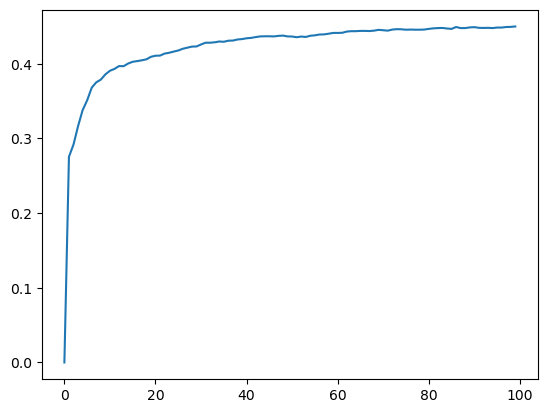

In [3]:
est_precs = torch.stack(utils.convert_state_dicts(true_runner.stored_vals["q_State_dicts"])["Precision"])
positive_rates = torch.mean((est_precs[..., lower_indices[0], lower_indices[1]] > 0).float(), dim=-1)
plt.plot(positive_rates)

In [4]:
torch.diag(torch.inverse(q_theta.Precision))
torch.logdet(q_theta.Precision)

tensor(132.0292, grad_fn=<WhereBackward0>)

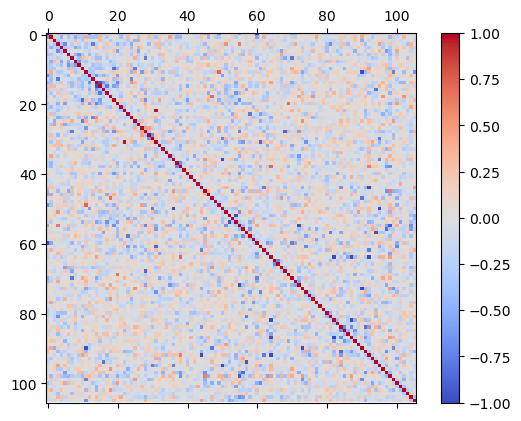

In [12]:
# Plot precision matrix in q_theta.Precision
fig, ax = plt.subplots()
cax = ax.matshow(q_theta.Precision.detach().numpy(), cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(cax)

In [13]:
lower_diag = q_theta.Precision[lower_indices[0], lower_indices[1]]
true_quantiles = torch.quantile(lower_diag, torch.tensor([0.9,0.8,0.7,0.6,0.5])).detach().numpy()
true_pos_quantiles = torch.quantile(lower_diag[lower_diag>0], torch.tensor([0.1, 0.01, 0.])).detach().numpy()
true_abs_quantiles = torch.quantile(torch.abs(lower_diag), torch.tensor([0.1, 0.01, 0.])).detach().numpy()

print("Value of quantile for all lower diag points", true_quantiles)
print("Value of quantile for positive lower diag points", true_pos_quantiles)
print("Value of quantiles for absolute data", true_abs_quantiles)

Value of quantile for all lower diag points [ 0.18457739  0.10539985  0.05304513  0.01401927 -0.0100731 ]
Value of quantile for positive lower diag points [1.0982362e-02 6.7550706e-04 9.1926377e-06]
Value of quantiles for absolute data [1.1898229e-02 7.4261293e-04 9.1926377e-06]


## Run Regulariseed Model

In [7]:
training_args = {
    "nepochs": 10000,
    "snapshot_freq": 1,
    "min_loss_val": -1e6}
true_stored_vals = {"Losses": [], "q_State_dicts": []}

l1_regs = torch.logspace(-1.7, -4, 101)
niters = torch.tensor([200]+[10]*100).int()
q_theta = models.NormalSymDensity(dim=dim, mean=torch.zeros(dim), Precision=torch.eye(dim))

theta_optimizer = utils.Prox_SGD([
    {"params":[q_theta.prec_diag], "l1_reg":0},
    {"params": [q_theta.prec_off], "l1_reg":100}
    ], lr=.1)

true_runner = runners.ScoreMatchingRunner(q_theta, theta_optimizer)
true_runner.init_dataset(data_tensor, batch_size=100, drop_last=True)
true_runner.set_grad_opts(control_method="clip", max_norm=0.5, norm_type=2)
for i, l1_reg in enumerate(l1_regs):
    # Update optimiser
    theta_optimizer.param_groups[1]["l1_reg"] = l1_reg.item()
    # Update training args
    training_args["niters"] = niters[i].item()
    try:
        true_runner.train(**training_args)
    except utils.NaNModel:
        print("Nan model")
    except IndexError:
        print("Index Error")

    for key, val in true_runner.stored_vals.items():
        # Add stored vals from this run to all stored_vals
        true_stored_vals[key] += val

change_points = (torch.cumsum(niters,0)/training_args["snapshot_freq"]).int()

torch.Size([1200, 106, 106])
tensor(0.4406)
tensor(0.9752)


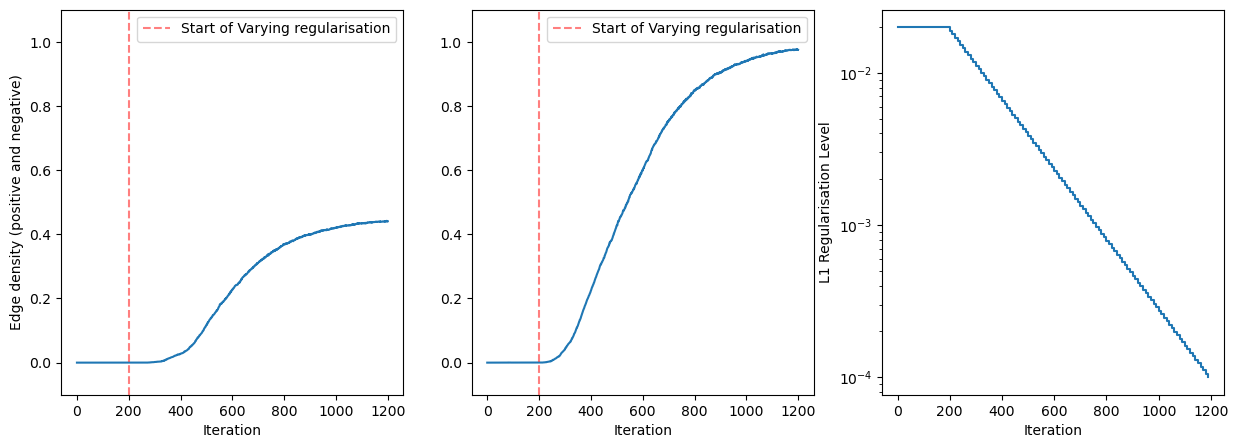

In [8]:
fig,ax = plt.subplots(ncols=3, figsize=(15,5))
q_theta_params = utils.convert_state_dicts(true_stored_vals["q_State_dicts"])
est_precs = torch.stack(q_theta_params["Precision"])
lower_diag = est_precs[:, lower_indices[0], lower_indices[1]]
print(est_precs.shape)
positive_rates = torch.mean((lower_diag>0.002).float(), dim=-1)
abs_positive_rates = torch.mean((torch.abs(lower_diag)>0.002).float(), dim=-1)
ax[0].plot(positive_rates)
ax[1].plot(abs_positive_rates)
ax[2].step(torch.cat((torch.zeros(1),change_points[:-1])), l1_regs, where="post")
ax[2].set_yscale("log")
true_index = torch.min(torch.nonzero(abs_positive_rates>0.2))
# Plot each change point as a vertical red line
for i in range(2):
    ax[i].set_xlabel("Iteration")
    ax[i].set_ylim(-0.1,1.1)
    ax[i].axvline(change_points[0], linestyle="--", color="red", alpha=0.5, label="Start of Varying regularisation")
    ax[i].legend()
ax[0].set_ylabel("Edge density (positive only)")
ax[0].set_ylabel("Edge density (positive and negative)")
ax[2].set_xlabel("Iteration")
ax[2].set_ylabel("L1 Regularisation Level")
print(positive_rates[-1])
print(abs_positive_rates[-1])

## Run Graphical Lasso

In [77]:
# Use scikit-learn to find the best l1_reg


mle_runner = GraphicalLasso(alpha=0.093, tol=1e-3, max_iter=1000)
mle_runner.fit(data_tensor.numpy())
lower_diag = mle_runner.precision_[lower_indices[0], lower_indices[1]]
nonzero_rate = np.mean(np.abs(lower_diag)>0)
print(nonzero_rate)

0.2508535489667565


In [64]:
# Use scikit-learn to find the best l1_reg
from sklearn.covariance import GraphicalLasso
mle_thresholds = [0.49, 0.349, 0.22, 0.128, 0.093]
mle_runners = []
for mle_threshold in mle_thresholds:
    temp_mle_runner = GraphicalLasso(alpha=mle_threshold, tol=1e-4, max_iter=1000)
    temp_mle_runner.fit(data_tensor.numpy())
    lower_diag = temp_mle_runner.precision_[lower_indices[0], lower_indices[1]]
    mle_runners.append(temp_mle_runner)
    nonzero_rate = np.mean(np.abs(lower_diag)>0)
    print(nonzero_rate)

0.04995507637017071
0.1004492362982929
0.1504043126684636
0.20161725067385444


In [10]:
true_prec = torch.tensor(mle_runner.precision_)
true_cov = torch.tensor(mle_runner.covariance_)
true_abs = torch.abs(true_prec)>0.002
true_prec_edges = true_prec[true_abs]
true_cov_edges = true_cov[true_abs]
print(torch.mean((true_prec_edges<0).float()).item())
print(torch.mean((true_cov_edges<0).float()).item())

0.5538555979728699
0.2328641414642334


## Compare Methods agreement.

In [11]:
mle_prec_edges = (torch.abs(torch.tensor(mle_runner.precision_))>0.002)[lower_indices[0], lower_indices[1]]
sm_prec_edges = (torch.abs(torch.tensor(true_runner.q_theta.Precision))>0.002)[lower_indices[0], lower_indices[1]]
torch.mean((mle_prec_edges == sm_prec_edges).float()).item()

/tmp/ipykernel_187001/3473022043.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sm_prec_edges = (torch.abs(torch.tensor(true_runner.q_theta.Precision))>0.002)[lower_indices[0], lower_indices[1]]


0.602515697479248

# Corrupted Case

In [14]:
# Create corrupted data
missing_prob = 0.5
mask = torch.bernoulli((1-missing_prob)*torch.ones_like(data_tensor))
missing_data = data_tensor*mask

## Variational

Value of quantile for all lower diag points [ 0.1212026   0.06970324  0.03610552  0.00629875 -0.02137109]
Value of quantile for positive lower diag points [1.1474077e-02 1.0588738e-03 2.1442631e-05]
Value of quantiles for absolute data [4.3215100e-02 1.4060101e-02 1.2365885e-03 9.4012976e-06]


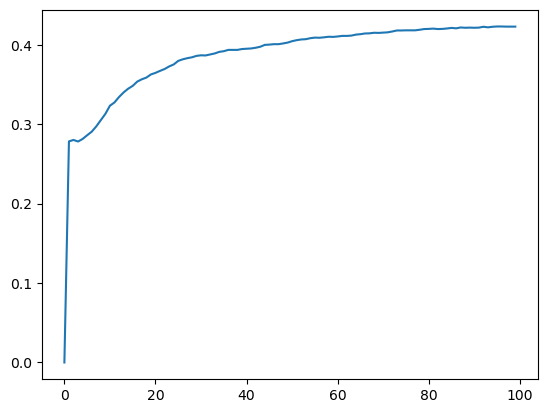

In [16]:
q_theta = models.NormalSymDensity(dim=dim, mean=torch.zeros(dim), Precision=torch.eye(dim))
p_phi = var_models.VariationalMLPConstVarNormal(dim=dim)
phi_optimizer = opt.Adam(p_phi.parameters(), lr=0.001)

theta_optimizer = opt.SGD(q_theta.parameters(), lr=.001)

temp_runner = runners.BiLevelMarginal(
    q_theta, p_phi, theta_optimizer, phi_optimizer,
    n_phi_step=10, do_iw=False, ncopies=10,inner_loss="fisher")
temp_runner.init_dataset(missing_data, mask, batch_size=100, drop_last=True)
temp_runner.set_grad_opts(control_method="clip", max_norm=0.5, norm_type=2)
temp_runner.train(1000, 1000, snapshot_freq=10)
# Get quantiles of lower diagonal of precision matrix
lower_indices = torch.tril_indices(dim, dim, offset=-1)
lower_diag = q_theta.Precision[lower_indices[0], lower_indices[1]]
variational_quantiles = torch.quantile(lower_diag, torch.tensor([0.9,0.8,0.7,0.6,0.5])).detach().numpy()
variational_pos_quantiles = torch.quantile(lower_diag[lower_diag>0], torch.tensor([0.1, 0.01, 0.])).detach().numpy()
variational_abs_quantiles = torch.quantile(torch.abs(lower_diag), torch.tensor([0.3,0.1, 0.01, 0.])).detach().numpy()

print("Value of quantile for all lower diag points", variational_quantiles)
print("Value of quantile for positive lower diag points", variational_pos_quantiles)
print("Value of quantiles for absolute data", variational_abs_quantiles)

est_precs = torch.stack(utils.convert_state_dicts(temp_runner.stored_vals["q_State_dicts"])["Precision"])
positive_rates = torch.mean((est_precs[..., lower_indices[0], lower_indices[1]] > 0).float(), dim=-1)
plt.plot(positive_rates)

In [108]:
training_args = {
    "nepochs": 10000,
    "snapshot_freq": 1,
    "min_loss_val": -1e6}
variational_stored_vals = {"Losses": [], "q_State_dicts": []}

l1_regs = torch.logspace(-0.7, -3, 101)
niters = torch.tensor([200]+[10]*100).int()
q_theta = models.NormalSymDensity(dim=dim, mean=torch.zeros(dim), Precision=torch.eye(dim))
p_phi = var_models.VariationalMLPConstVarNormal(dim=dim)
phi_optimizer = opt.Adam(p_phi.parameters(), lr=0.01)

theta_optimizer = utils.Prox_SGD([
    {"params":[q_theta.prec_diag], "l1_reg":0.},
    {"params": [q_theta.prec_off], "l1_reg":.2}
    ], lr=.01)

variational_runner = runners.BiLevelMarginal(q_theta, p_phi, theta_optimizer, phi_optimizer,
                                 n_phi_step=10, do_iw=False, ncopies=10, inner_loss="fisher")
variational_runner.init_dataset(missing_data, mask, batch_size=100, drop_last=True)
variational_runner.set_grad_opts(control_method="clip", max_norm=0.5, norm_type=2)
variational_levels = reg_gridsearch(variational_runner, density_range=(0.0, 0.3), 
                        abs_density_range=(0.001,0.8),start_range=(0.00001, 0.1),
                        steps=100, threshold=variational_pos_quantiles[0], abs_threshold=variational_abs_quantiles[0],
                        max_recur=5, log=True, abs=False)

Upper extrapolated
New range: (0.27825599908828735, 0.0007220808765850961)
Upper extrapolated
New range: (0.5392152667045593, 0.002263923641294241)
Upper extrapolated
New range: (0.9905177354812622, 0.0023926040157675743)
Upper extrapolated
Lower extrapolated
New range: (1.934813380241394, 0.0013017518213018775)
Upper extrapolated
New range: (4.356080055236816, 0.0013017518213018775)


In [17]:
training_args = {
    "nepochs": 10000,
    "snapshot_freq": 1,
    "min_loss_val": -1e6}
variational_stored_vals = {"Losses": [], "q_State_dicts": []}

l1_regs = torch.logspace(1, -4, 201)
niters = torch.tensor([200]+[10]*200).int()
change_points = (torch.cumsum(niters,0)/training_args["snapshot_freq"]).int()
q_theta = models.NormalSymDensity(dim=dim, mean=torch.zeros(dim), Precision=torch.eye(dim))
p_phi = var_models.VariationalMLPConstVarNormal(dim=dim)
phi_optimizer = opt.Adam(p_phi.parameters(), lr=0.001)

theta_optimizer = utils.Prox_SGD([
    {"params":[q_theta.prec_diag], "l1_reg":0.},
    {"params": [q_theta.prec_off], "l1_reg":.2}
    ], lr=.0005)

variational_runner = runners.BiLevelMarginal(
    q_theta, p_phi, theta_optimizer, phi_optimizer,
    n_phi_step=5, do_iw=False, ncopies=10,inner_loss="fisher")
variational_runner.init_dataset(missing_data, mask, batch_size=100, drop_last=True)
variational_runner.set_grad_opts(control_method="clip", max_norm=0.5, norm_type=2)
for i, l1_reg in enumerate(l1_regs):
    # Update optimiser
    theta_optimizer.param_groups[1]["l1_reg"] = l1_reg.item()
    # Update training args
    training_args["niters"] = niters[i].item()
    # Run training
    variational_runner.train(**training_args)
    
    # Store results
    variational_runner.stored_vals.pop("p_State_dicts")
    for key, val in variational_runner.stored_vals.items():
        # Add stored vals from this run to all stored_vals
        variational_stored_vals[key] += val


In [18]:
niters = torch.tensor([200]+[10]*200).int()
change_points = (torch.cumsum(niters,0)/training_args["snapshot_freq"]).int()

torch.Size([2200, 106, 106])
tensor(0.4226)
tensor(0.9935)


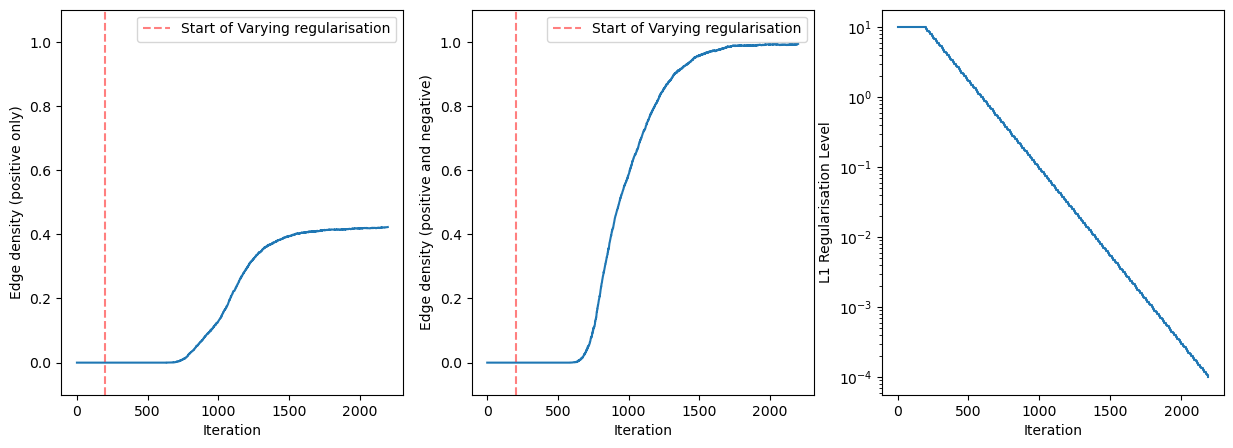

In [26]:
fig,ax = plt.subplots(ncols=3, figsize=(15,5))
q_theta_params = utils.convert_state_dicts(variational_stored_vals["q_State_dicts"])
est_precs = torch.stack(q_theta_params["Precision"])
lower_diag = est_precs[:, lower_indices[0], lower_indices[1]]
print(est_precs.shape)
positive_rates = torch.mean((lower_diag>0.0005).float(),dim=-1)
abs_positive_rates = torch.mean((torch.abs(lower_diag)>0.0005).float(), dim=-1)
ax[0].plot(positive_rates)
ax[1].plot(abs_positive_rates)
ax[2].step(torch.cat((torch.zeros(1),change_points[:-1])), l1_regs, where="post")
ax[2].set_yscale("log")

variational_nonabs_index = torch.min(torch.nonzero(positive_rates>0.25))
# variational_abs_index = torch.min(torch.nonzero(abs_positive_rates>0.5))
# Plot each change point as a vertical red line
for i in range(2):
    ax[i].set_xlabel("Iteration")
    ax[i].set_ylim(-0.1,1.1)
    ax[i].axvline(change_points[0], linestyle="--", color="red", alpha=0.5, label="Start of Varying regularisation")
    ax[i].legend()
ax[0].set_ylabel("Edge density (positive only)")
ax[1].set_ylabel("Edge density (positive and negative)")
ax[2].set_xlabel("Iteration")
ax[2].set_ylabel("L1 Regularisation Level")
print(positive_rates[-1])
print(abs_positive_rates[-1])

In [20]:
print("Changes in angle")
print(pos_rate_reg(torch.mean((lower_diag[change_points-1]>0.007).float(), dim=-1), type='changes'))
print(pos_rate_reg(torch.mean((torch.abs(lower_diag[change_points-1])>0.007).float(), dim=-1), type='changes'))
print("")
print("All Negative Angles")
print(pos_rate_reg(torch.mean((lower_diag[change_points-1]>0.007).float(), dim=-1), type='all'))
print(pos_rate_reg(torch.mean((torch.abs(lower_diag[change_points-1])>0.007).float(), dim=-1), type='all'))
print("")
print("Changes in angle all")
print(pos_rate_reg(torch.mean((lower_diag>0.007).float(), dim=-1), type='changes'))
print(pos_rate_reg(torch.mean((torch.abs(lower_diag)>0.007).float(), dim=-1), type='changes'))
print("")
print("All negative angles all")
print(pos_rate_reg(torch.mean((lower_diag>0.007).float(), dim=-1), type='all'))
print(pos_rate_reg(torch.mean((torch.abs(lower_diag)>0.007).float(), dim=-1), type='all'))
print("\n")
print("Changes in Height")
print(pos_rate_reg(torch.mean((lower_diag[change_points-1]>0.007).float(), dim=-1), type='changes', angles=False))
print(pos_rate_reg(torch.mean((torch.abs(lower_diag[change_points-1])>0.007).float(), dim=-1), type='changes', angles=False))
print("")
print("All Negative Height")
print(pos_rate_reg(torch.mean((lower_diag[change_points-1]>0.007).float(), dim=-1), type='all', angles=False))
print(pos_rate_reg(torch.mean((torch.abs(lower_diag[change_points-1])>0.007).float(), dim=-1), type='all', angles=False))
print("")
print("Changes in Height all")
print(pos_rate_reg(torch.mean((lower_diag>0.007).float(), dim=-1), type='changes', angles=False))
print(pos_rate_reg(torch.mean((torch.abs(lower_diag)>0.007).float(), dim=-1), type='changes', angles=False))
print("")
print("All negative Height all")
print(pos_rate_reg(torch.mean((lower_diag>0.007).float(), dim=-1), type='all', angles=False))
print(pos_rate_reg(torch.mean((torch.abs(lower_diag)>0.007).float(), dim=-1), type='all', angles=False))


Changes in angle
tensor(0.1435)
tensor(0.0721)

All Negative Angles
tensor(0.1435)
tensor(0.0721)

Changes in angle all
tensor(93.4418)
tensor(102.6133)

All negative angles all
tensor(105.5127)
tensor(113.7120)


Changes in Height
tensor(0.0007)
tensor(0.0004)

All Negative Height
tensor(0.0007)
tensor(0.0004)

Changes in Height all
tensor(0.0501)
tensor(0.0589)

All negative Height all
tensor(0.0564)
tensor(0.0654)


In [21]:
out = threshold_selector(torch.abs(lower_diag)[change_points-1], threshold=0.01, iters=3, steps=100, type="changes", angles=False)
print(out)
scores = torch.abs(lower_diag)
# Get positive rates for thresholds in shape (steps, nchange_points)
temp_positive_rates = torch.mean((scores > out).float(), dim=-1)
print(temp_positive_rates.shape)
print(pos_rate_reg(temp_positive_rates))

Reg levels at current range are: (tensor(0.0311), tensor(0.))
Reg levels at current range are: (tensor(0.0106), tensor(0.0070))
Reg levels at current range are: (tensor(0.0102), tensor(0.0095))
0.001261910772882402
torch.Size([2200])
tensor(210.9511)


### Plot Performance

AUC: 0.901


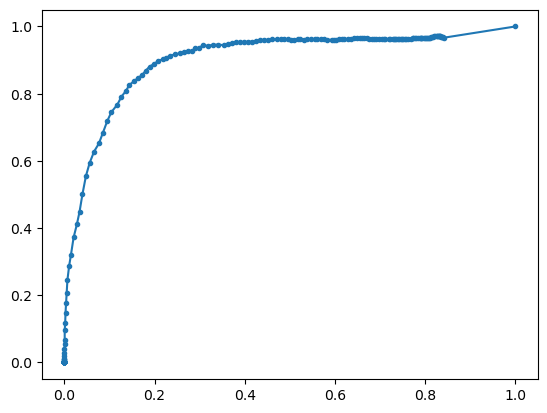

In [22]:
niters = torch.tensor([200]+[10]*200).int()
change_points = (torch.cumsum(niters,0)/training_args["snapshot_freq"]).int()
est_precs = torch.stack([variational_stored_vals["q_State_dicts"][index]["Precision"] for index in change_points-1])
true_prec = true_stored_vals["q_State_dicts"][true_index]["Precision"]

# Plot ROC curve from this

est_abs = torch.abs(est_precs)>0.01
true_abs = (torch.abs(true_prec)>0.002).float()
tpr, fpr = utils.data.tpr(true_abs, est_abs ), utils.data.fpr(true_abs, est_abs)
# Append 0 and 1 to beginning and end of fpr and tpr
tpr = torch.cat((torch.zeros(1), tpr, torch.ones(1)))
fpr = torch.cat((torch.zeros(1), fpr, torch.ones(1)))
print(f"AUC: {utils.data.AUC(tpr, fpr):.3f}")
# plot line plot with dots at points
plt.plot(fpr, tpr, marker = "o", label="Variational", markersize=3)
plt.show()

AUC: 0.825


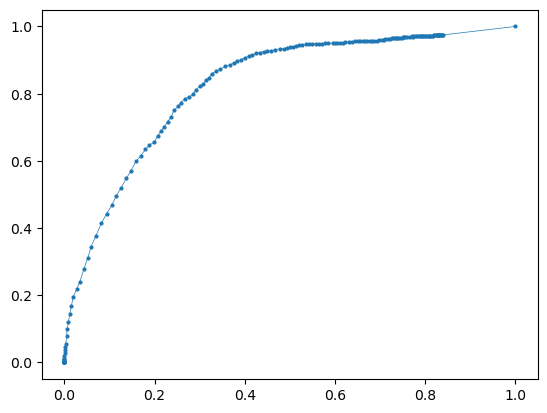

In [68]:
change_points = (torch.cumsum(niters,0)/training_args["snapshot_freq"]).int()
est_precs = torch.stack([variational_stored_vals["q_State_dicts"][index]["Precision"] for index in change_points-1])
true_prec = true_stored_vals["q_State_dicts"][true_index]["Precision"]

# Plot ROC curve from this

est_abs = torch.abs(est_precs)>0.01
true_abs = (torch.abs(torch.tensor(mle_runners[3].precision_))>0).float()
tpr, fpr = utils.data.tpr(true_abs, est_abs ), utils.data.fpr(true_abs, est_abs)
# Append 0 and 1 to beginning and end of fpr and tpr
tpr = torch.cat((torch.zeros(1), tpr, torch.ones(1)))
fpr = torch.cat((torch.zeros(1), fpr, torch.ones(1)))
print(f"AUC: {utils.data.AUC(tpr, fpr):.3f}")
# plot line plot with dots at points
plt.plot(fpr, tpr, marker = "o", label="Variational", markersize=2, linewidth=0.5)
plt.show()

In [136]:
torch.nonzero(fpr>0.02)[0,0]
print(torch.mean((est_precs[75][est_abs[75]]<0).float()))
print(est_precs[75][~est_abs[75]])

tensor(0.9124)
tensor([-0.0000, -0.0000, -0.0010,  ...,  0.0000,  0.0065,  0.0036])


## MissDiff-Param

Value of quantile for all lower diag points [ 0.05029124  0.02693526  0.01087529 -0.00275932 -0.01494832]
Value of quantile for positive lower diag points [5.2056764e-03 4.5642877e-04 7.6255428e-06]
Value of quantiles for absolute data [6.6611590e-03 5.9158757e-04 6.9774114e-06]


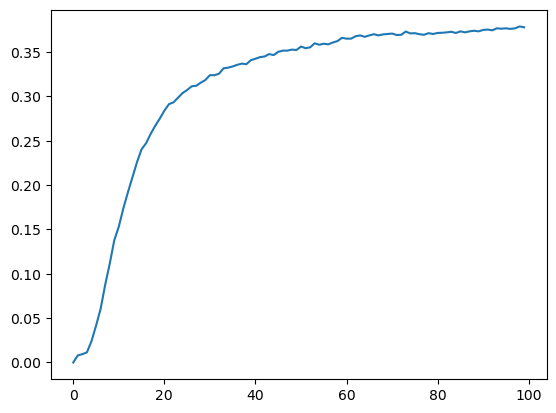

In [32]:
q_theta = models.NormalSymDensity(dim=dim, mean=torch.zeros(dim), Precision=torch.eye(dim))
zero_imputer = var_models.ConstantImputer(torch.zeros(1))
theta_optimizer = opt.SGD(q_theta.parameters(), lr=.1)

temp_runner = runners.ImputingZerodScoreMatchingRunner(
    q_theta, zero_imputer, theta_optimizer)
temp_runner.init_dataset(missing_data, mask, batch_size=100, drop_last=True)
temp_runner.set_grad_opts(control_method="clip", max_norm=0.5, norm_type=2)
temp_runner.train(1000, 1000, snapshot_freq=10)
# Get quantiles of lower diagonal of precision matrix
lower_indices = torch.tril_indices(dim, dim, offset=-1)
lower_diag = q_theta.Precision[lower_indices[0], lower_indices[1]]
missdiff_quantiles = torch.quantile(lower_diag, torch.tensor([0.9,0.8,0.7,0.6,0.5])).detach().numpy()
missdiff_pos_quantiles = torch.quantile(lower_diag[lower_diag>0], torch.tensor([0.1, 0.01, 0.])).detach().numpy()
missdiff_abs_quantiles = torch.quantile(torch.abs(lower_diag), torch.tensor([0.1, 0.01, 0.])).detach().numpy()
print("Value of quantile for all lower diag points", missdiff_quantiles)
print("Value of quantile for positive lower diag points", missdiff_pos_quantiles)
print("Value of quantiles for absolute data", missdiff_abs_quantiles)

est_precs = torch.stack(utils.convert_state_dicts(temp_runner.stored_vals["q_State_dicts"])["Precision"])
positive_rates = torch.mean((est_precs[..., lower_indices[0], lower_indices[1]] > 0).float(), dim=-1)
plt.plot(positive_rates)

torch.Size([8742])


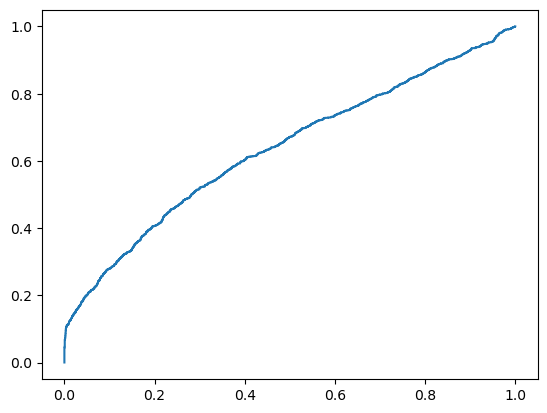

tensor([ 200,  210,  220,  230,  240,  250,  260,  270,  280,  290,  300,  310,
         320,  330,  340,  350,  360,  370,  380,  390,  400,  410,  420,  430,
         440,  450,  460,  470,  480,  490,  500,  510,  520,  530,  540,  550,
         560,  570,  580,  590,  600,  610,  620,  630,  640,  650,  660,  670,
         680,  690,  700,  710,  720,  730,  740,  750,  760,  770,  780,  790,
         800,  810,  820,  830,  840,  850,  860,  870,  880,  890,  900,  910,
         920,  930,  940,  950,  960,  970,  980,  990, 1000, 1010, 1020, 1030,
        1040, 1050, 1060, 1070, 1080, 1090, 1100, 1110, 1120, 1130, 1140, 1150,
        1160, 1170, 1180, 1190, 1200], dtype=torch.int32)

In [106]:
est_prec = temp_runner.q_theta.Precision.detach().clone()
true_prec = true_stored_vals["q_State_dicts"][true_index]["Precision"]
true_abs = (torch.abs(true_prec)>0.002).float()
roc_tpr, roc_fpr = utils.data.roc(true_abs, torch.abs(est_prec))
print(roc_tpr.shape)
plt.plot(roc_fpr, roc_tpr)
plt.show()
change_points

Try regularisation grid search

In [ ]:
training_args = {
    "nepochs": 10000,
    "snapshot_freq": 1,
    "min_loss_val": -1e6}
missdiff_stored_vals = {"Losses": [], "q_State_dicts": []}

l1_regs = torch.cat((torch.logspace(1, -4, 201),torch.zeros(1)))
niters = torch.tensor([200]+[10]*200+[50]).int()
q_theta = models.NormalSymDensity(dim=dim, mean=torch.zeros(dim), Precision=torch.eye(dim))
zero_imputer = var_models.ConstantImputer(torch.zeros(1))

theta_optimizer = utils.Prox_SGD([
    {"params":[q_theta.prec_diag], "l1_reg":0.},
    {"params": [q_theta.prec_off], "l1_reg":0.02}
    ], lr=.1)

missdiff_runner = runners.ImputingZerodScoreMatchingRunner(q_theta, zero_imputer, theta_optimizer)
missdiff_runner.init_dataset(missing_data, mask, batch_size=100, drop_last=True)
missdiff_runner.set_grad_opts(control_method="clip", max_norm=0.5, norm_type=2)

levels = reg_gridsearch(missdiff_runner, density_range=(0.0, 0.3), 
                        abs_density_range=(0.001,0.8),start_range=(0.00001, 0.1),
                        steps=100, threshold=missdiff_pos_quantiles[0], abs_threshold=missdiff_abs_quantiles[0],
                        max_recur=5, log=True, abs=False)

In [28]:
levels = (0.025348268449306488, 6.20534410700202e-05)

In [29]:
training_args = {
    "nepochs": 10000,
    "snapshot_freq": 1,
    "min_loss_val": -1e6}
missdiff_stored_vals = {"Losses": [], "q_State_dicts": []}

# l1_regs = torch.cat((torch.logspace(np.log10(levels[0]), np.log10(levels[1]), 101),torch.zeros(1)))
l1_regs = torch.cat((torch.logspace(1, -4, 201),torch.zeros(1)))
niters = torch.tensor([200]+[10]*200+[50]).int()
q_theta = models.NormalSymDensity(dim=dim, mean=torch.zeros(dim), Precision=torch.eye(dim))
zero_imputer = var_models.ConstantImputer(torch.zeros(1))

theta_optimizer = utils.Prox_SGD([
    {"params":[q_theta.prec_diag], "l1_reg":0.},
    {"params": [q_theta.prec_off], "l1_reg":0.02}
    ], lr=.0005)

missdiff_runner = runners.ImputingZerodScoreMatchingRunner(q_theta, zero_imputer, theta_optimizer)
missdiff_runner.init_dataset(missing_data, mask, batch_size=100, drop_last=True)
missdiff_runner.set_grad_opts(control_method="clip", max_norm=0.5, norm_type=2)
for i, l1_reg in enumerate(l1_regs):
    # Update optimiser
    theta_optimizer.param_groups[1]["l1_reg"] = l1_reg.item()
    # Update training args
    training_args["niters"] = niters[i].item()
    try:
        missdiff_runner.train(**training_args)
    except utils.NaNModel:
        print("Nan model")
    except IndexError:
        print("Index Error")
    for key, val in missdiff_runner.stored_vals.items():
        # Add stored vals from this run to all stored_vals
        missdiff_stored_vals[key] += val

change_points = (torch.cumsum(niters,0)/training_args["snapshot_freq"]).int()

torch.Size([2250, 131, 131])
tensor(0.0621)
tensor(0.9957)


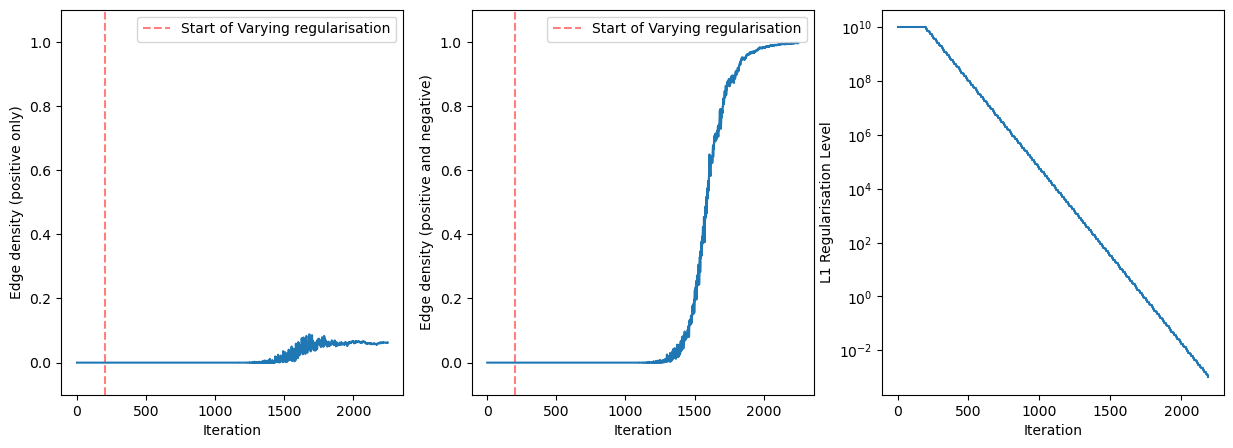

In [76]:
niters = torch.tensor([200]+[10]*200).int()
change_points = (torch.cumsum(niters,0)/training_args["snapshot_freq"]).int()

fig,ax = plt.subplots(ncols=3, figsize=(15,5))
q_theta_params = utils.convert_state_dicts(missdiff_stored_vals["q_State_dicts"])
est_precs = torch.stack(q_theta_params["Precision"])
lower_diag = est_precs[:, lower_indices[0], lower_indices[1]]
print(est_precs.shape)
positive_rates = torch.mean((lower_diag>0.00).float(),dim=-1)
abs_positive_rates = torch.mean((torch.abs(lower_diag)>0.000002).float(), dim=-1)
ax[0].plot(positive_rates)
ax[1].plot(abs_positive_rates)
ax[2].step(torch.cat((torch.zeros(1),change_points[:-1])), l1_regs, where="post")
ax[2].set_yscale("log")
# missdiff_index = torch.min(torch.nonzero(abs_positive_rates>0.5))
# Plot each change point as a vertical red line
for i in range(2):
    ax[i].set_xlabel("Iteration")
    ax[i].set_ylim(-0.1,1.1)
    ax[i].axvline(change_points[0], linestyle="--", color="red", alpha=0.5, label="Start of Varying regularisation")
    ax[i].legend()
ax[0].set_ylabel("Edge density (positive only)")
ax[1].set_ylabel("Edge density (positive and negative)")
ax[2].set_xlabel("Iteration")
ax[2].set_ylabel("L1 Regularisation Level")
print(positive_rates[-1])
print(abs_positive_rates[-1])

### Plot Results

AUC: 0.915


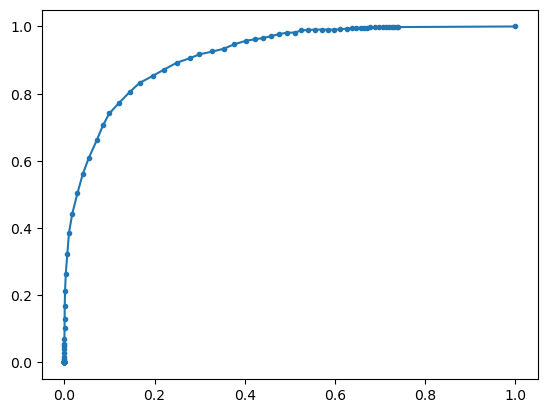

In [63]:
est_precs = torch.stack([missdiff_stored_vals["q_State_dicts"][index]["Precision"] for index in change_points-1])
true_prec = true_stored_vals["q_State_dicts"][true_index]["Precision"]

# Plot ROC curve from this

est_abs = torch.abs(est_precs)>0.0002
true_abs = (torch.abs(true_prec)>0.002).float()
tpr, fpr = utils.data.tpr(true_abs, est_abs ), utils.data.fpr(true_abs, est_abs)
# Append 0 and 1 to begining and end of fpr and tpr
tpr = torch.cat((torch.zeros(1), tpr, torch.ones(1)))
fpr = torch.cat((torch.zeros(1), fpr, torch.ones(1)))
print(f"AUC: {utils.data.AUC(tpr, fpr):.3f}")
# plot line plot with dots at points
plt.plot(fpr, tpr, marker = "o", label="Variational", markersize=3)
plt.show()

AUC: 0.926


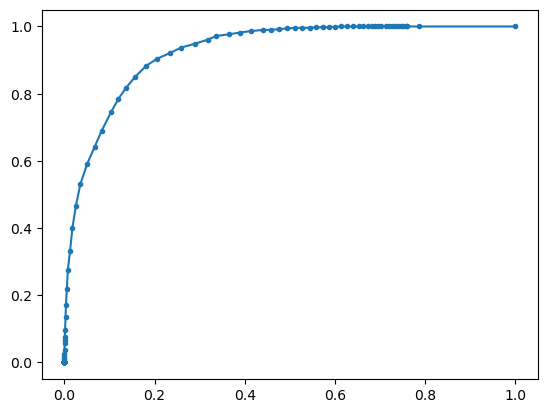

In [33]:
est_precs = torch.stack([missdiff_stored_vals["q_State_dicts"][index]["Precision"] for index in change_points-1])
true_prec = true_stored_vals["q_State_dicts"][true_index]["Precision"]

# Plot ROC curve from this

est_abs = torch.abs(est_precs)>0.0002
true_abs = (torch.abs(torch.tensor(mle_runner.precision_))>0.000).float()
tpr, fpr = utils.data.tpr(true_abs, est_abs ), utils.data.fpr(true_abs, est_abs)
# Append 0 and 1 to begining and end of fpr and tpr
tpr = torch.cat((torch.zeros(1), tpr, torch.ones(1)))
fpr = torch.cat((torch.zeros(1), fpr, torch.ones(1)))
print(f"AUC: {utils.data.AUC(tpr, fpr):.3f}")
# plot line plot with dots at points
plt.plot(fpr, tpr, marker = "o", label="Variational", markersize=3)
plt.show()

In [143]:
select_ind = torch.nonzero(fpr>0.2)[0,0]
print(select_ind)


print(torch.mean((est_precs[select_ind][est_abs[select_ind]]<0).float()))
print(est_precs[select_ind][~est_abs[select_ind]])

tensor(47)
tensor(0.9423)
tensor([-0.0000, 0.0013, 0.0001,  ..., 0.0017, 0.0002, 0.0002])


## Importance Weighting

Value of quantile for all lower diag points [ 0.06507645  0.03199651  0.00916356 -0.01015587 -0.02828975]
Value of quantile for positive lower diag points [5.7894206e-03 5.0156977e-04 9.8547825e-06]
Value of quantiles for absolute data [9.5883496e-03 8.7703974e-04 9.8547825e-06]


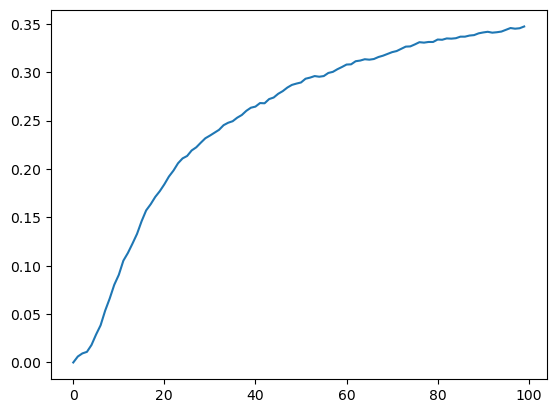

In [42]:
q_theta = models.NormalSymDensity(dim=dim, mean=torch.zeros(dim), Precision=torch.eye(dim))
fixed_phi = var_models.VariationalConstantNormal(
        dim=dim, mean=torch.zeros(dim), std=0.1 * torch.ones(dim)
    )

theta_optimizer = opt.SGD(q_theta.parameters(), lr=.1)

temp_runner = runners.IWScoreMatchingRunner(
    q_theta, fixed_phi, theta_optimizer, ncopies=10)
temp_runner.init_dataset(missing_data, mask, batch_size=100, drop_last=True)
temp_runner.set_grad_opts(control_method="clip", max_norm=0.5, norm_type=2)
temp_runner.train(1000, 1000, snapshot_freq=10)

# Get quantiles of lower diagonal of precision matrix
lower_indices = torch.tril_indices(dim, dim, offset=-1)
lower_diag = q_theta.Precision[lower_indices[0], lower_indices[1]]
iw_quantiles = torch.quantile(lower_diag, torch.tensor([0.9,0.8,0.7,0.6,0.5])).detach().numpy()
iw_pos_quantiles = torch.quantile(lower_diag[lower_diag>0], torch.tensor([0.1, 0.01, 0.])).detach().numpy()
iw_abs_quantiles = torch.quantile(torch.abs(lower_diag), torch.tensor([0.1, 0.01, 0.])).detach().numpy()
print("Value of quantile for all lower diag points", iw_quantiles)
print("Value of quantile for positive lower diag points", iw_pos_quantiles)
print("Value of quantiles for absolute data", iw_abs_quantiles)

# Plot positive rates over time
est_precs = torch.stack(utils.convert_state_dicts(temp_runner.stored_vals["q_State_dicts"])["Precision"])
positive_rates = torch.mean((est_precs[..., lower_indices[0], lower_indices[1]] > 0).float(), dim=-1)
plt.plot(positive_rates)

In [37]:
training_args = {
    "nepochs": 10000,
    "snapshot_freq": 1,
    "min_loss_val": -1e6}
iw_stored_vals = {"Losses": [], "q_State_dicts": []}

l1_regs = torch.logspace(-1.7, -4, 101)
niters = torch.tensor([200]+[10]*100).int()
q_theta = models.NormalSymDensity(dim=dim, mean=torch.zeros(dim), Precision=torch.eye(dim))
fixed_phi = var_models.VariationalConstantNormal(
        dim=dim, mean=torch.zeros(dim), std=0.1 * torch.ones(dim)
    )

theta_optimizer = utils.Prox_SGD([
    {"params":[q_theta.prec_diag], "l1_reg":0.},
    {"params": [q_theta.prec_off], "l1_reg":.02}
    ], lr=.1)

iw_runner = runners.IWScoreMatchingRunner(
    q_theta, fixed_phi, theta_optimizer, ncopies=10)
iw_runner.init_dataset(missing_data, mask, batch_size=100, drop_last=True)
iw_runner.set_grad_opts(control_method="clip", max_norm=0.5, norm_type=2)
for i, l1_reg in enumerate(l1_regs):
    # Update optimiser
    theta_optimizer.param_groups[1]["l1_reg"] = l1_reg.item()
    # Update training args
    training_args["niters"] = niters[i].item()
    try:
        iw_runner.train(**training_args)
    except utils.NaNModel:
        print("Nan model")
    except IndexError:
        print("Index Error")
    for key, val in iw_runner.stored_vals.items():
        # Add stored vals from this run to all stored_vals
        iw_stored_vals[key] += val

change_points = (torch.cumsum(niters,0)/training_args["snapshot_freq"]).int()

torch.Size([1200, 94, 94])
tensor(0.1576)
tensor(0.6420)


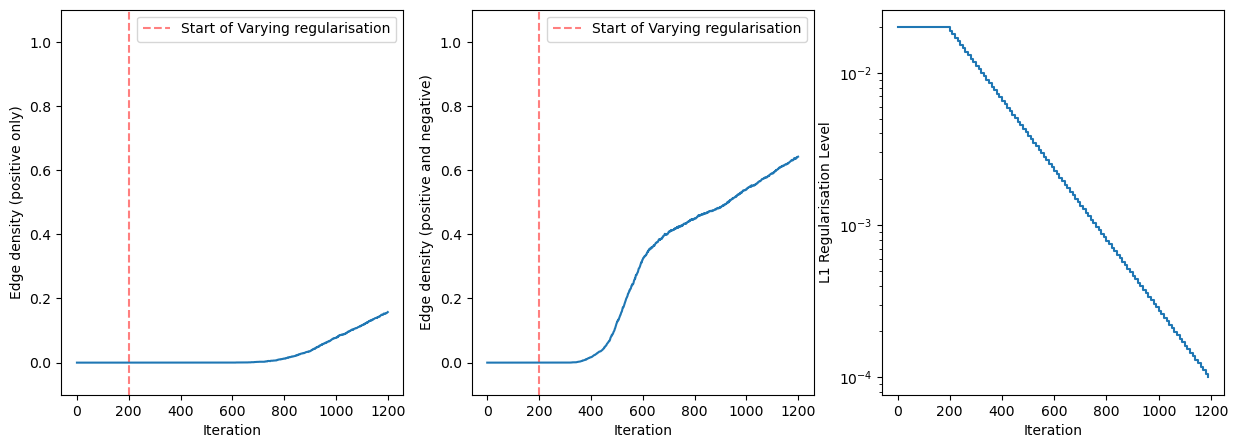

In [40]:
fig,ax = plt.subplots(ncols=3, figsize=(15,5))
q_theta_params = utils.convert_state_dicts(iw_stored_vals["q_State_dicts"])
est_precs = torch.stack(q_theta_params["Precision"])
lower_diag = est_precs[:, lower_indices[0], lower_indices[1]]
print(est_precs.shape)
positive_rates = torch.mean((lower_diag>0.002).float(),dim=-1)
abs_positive_rates = torch.mean((torch.abs(lower_diag)>0.002).float(), dim=-1)
ax[0].plot(positive_rates)
ax[1].plot(abs_positive_rates)
ax[2].step(torch.cat((torch.zeros(1),change_points[:-1])), l1_regs, where="post")
ax[2].set_yscale("log")
iw_index = torch.min(torch.nonzero(abs_positive_rates>0.5))
# Plot each change point as a vertical red line
for i in range(2):
    ax[i].set_xlabel("Iteration")
    ax[i].set_ylim(-0.1,1.1)
    ax[i].axvline(change_points[0], linestyle="--", color="red", alpha=0.5, label="Start of Varying regularisation")
    ax[i].legend()
ax[0].set_ylabel("Edge density (positive only)")
ax[1].set_ylabel("Edge density (positive and negative)")
ax[2].set_xlabel("Iteration")
ax[2].set_ylabel("L1 Regularisation Level")
print(positive_rates[-1])
print(abs_positive_rates[-1])

### Plot Results

AUC: 0.810


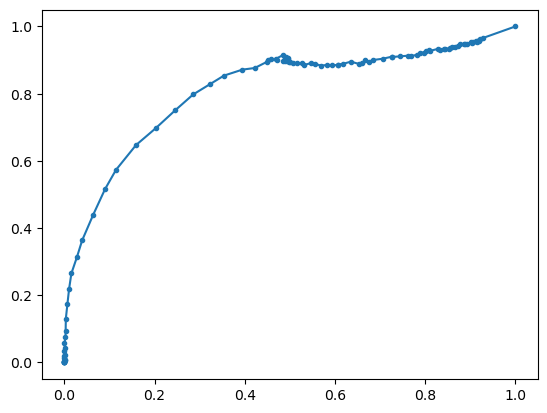

In [90]:
est_precs = torch.stack([iw_stored_vals["q_State_dicts"][index]["Precision"] for index in change_points-1])
true_prec = true_stored_vals["q_State_dicts"][true_index]["Precision"]

# Plot ROC curve from this

est_abs = torch.abs(est_precs)>0.002
true_abs = (torch.abs(true_prec)>0.002).float()
tpr, fpr = utils.data.tpr(true_abs, est_abs ), utils.data.fpr(true_abs, est_abs)
# Append 0 and 1 to begining and end of fpr and tpr
tpr = torch.cat((torch.zeros(1), tpr, torch.ones(1)))
fpr = torch.cat((torch.zeros(1), fpr, torch.ones(1)))
print(f"AUC: {utils.data.AUC(tpr, fpr):.3f}")
# plot line plot with dots at points
plt.plot(fpr, tpr, marker = "o", label="Variational", markersize=3)
plt.show()

AUC: 0.866


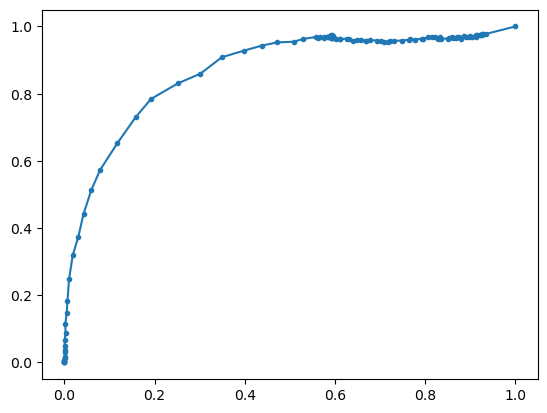

In [94]:
est_precs = torch.stack([iw_stored_vals["q_State_dicts"][index]["Precision"] for index in change_points-1])
true_prec = true_stored_vals["q_State_dicts"][true_index]["Precision"]

# Plot ROC curve from this

est_abs = torch.abs(est_precs)>0.002
true_abs = (torch.abs(torch.tensor(mle_runner.precision_))>0.002).float()
tpr, fpr = utils.data.tpr(true_abs, est_abs ), utils.data.fpr(true_abs, est_abs)
# Append 0 and 1 to begining and end of fpr and tpr
tpr = torch.cat((torch.zeros(1), tpr, torch.ones(1)))
fpr = torch.cat((torch.zeros(1), fpr, torch.ones(1)))
print(f"AUC: {utils.data.AUC(tpr, fpr):.3f}")
# plot line plot with dots at points
plt.plot(fpr, tpr, marker = "o", label="Variational", markersize=3)
plt.show()

## EM

Value of quantile for all lower diag points [ 0.06519424  0.0324886   0.00945634 -0.01025095 -0.0281256 ]
Value of quantile for positive lower diag points [0.00700441 0.00070744 0.00014615]
Value of quantiles for absolute data [9.7479830e-03 8.9089689e-04 1.4789356e-05]


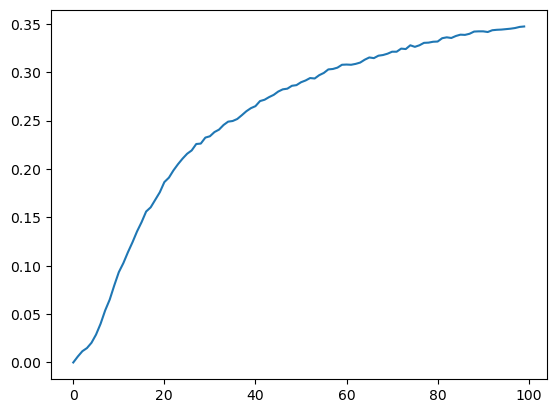

In [64]:
q_theta = models.NormalSymDensity(dim=dim, mean=torch.zeros(dim), Precision=torch.eye(dim))
fixed_phi = var_models.VariationalConstantNormal(
        dim=dim, mean=torch.zeros(dim), std=0.1 * torch.ones(dim)
    )

theta_optimizer = opt.SGD(q_theta.parameters(), lr=.1)

temp_runner = runners.EMScoreMatchingRunner(
    q_theta, fixed_phi, theta_optimizer, ncopies=10)
temp_runner.init_dataset(missing_data, mask, batch_size=100, drop_last=True)
temp_runner.set_grad_opts(control_method="clip", max_norm=0.5, norm_type=2)
temp_runner.train(1000, 1000, snapshot_freq=10)

# Get quantiles of lower diagonal of precision matrix
lower_indices = torch.tril_indices(dim, dim, offset=-1)
lower_diag = q_theta.Precision[lower_indices[0], lower_indices[1]]
em_quantiles = torch.quantile(lower_diag, torch.tensor([0.9,0.8,0.7,0.6,0.5])).detach().numpy()
em_pos_quantiles = torch.quantile(lower_diag[lower_diag>0], torch.tensor([0.1, 0.01, 0.])).detach().numpy()
em_abs_quantiles = torch.quantile(torch.abs(lower_diag), torch.tensor([0.1, 0.01, 0.])).detach().numpy()
print("Value of quantile for all lower diag points", em_quantiles)
print("Value of quantile for positive lower diag points", em_pos_quantiles)
print("Value of quantiles for absolute data", em_abs_quantiles)

# Plot positive rates over time
est_precs = torch.stack(utils.convert_state_dicts(temp_runner.stored_vals["q_State_dicts"])["Precision"])
positive_rates = torch.mean((est_precs[..., lower_indices[0], lower_indices[1]] > 0).float(), dim=-1)
plt.plot(positive_rates)

In [49]:
training_args = {
    "nepochs": 10000,
    "snapshot_freq": 1,
    "min_loss_val": -1e6}
em_stored_vals = {"Losses": [], "q_State_dicts": []}

l1_regs = torch.logspace(-1.7, -4, 101)
niters = torch.tensor([200]+[10]*100).int()
q_theta = models.NormalSymDensity(dim=dim, mean=torch.zeros(dim), Precision=torch.eye(dim))
fixed_phi = var_models.VariationalConstantNormal(
        dim=dim, mean=torch.zeros(dim), std=0.1 * torch.ones(dim)
    )

theta_optimizer = utils.Prox_SGD([
    {"params":[q_theta.prec_diag], "l1_reg":0.},
    {"params": [q_theta.prec_off], "l1_reg":0.02}
    ], lr=.1)

em_runner = runners.EMScoreMatchingRunner(
    q_theta, fixed_phi, theta_optimizer, ncopies=10)
em_runner.init_dataset(missing_data, mask, batch_size=100, drop_last=True)
em_runner.set_grad_opts(control_method="clip", max_norm=0.5, norm_type=2)
for i, l1_reg in enumerate(l1_regs):
    # Update optimiser
    theta_optimizer.param_groups[1]["l1_reg"] = l1_reg.item()
    # Update training args
    training_args["niters"] = niters[i].item()
    try:
        em_runner.train(**training_args)
    except utils.NaNModel:
        print("Nan model")
    except IndexError:
        print("Index Error")
    for key, val in em_runner.stored_vals.items():
        # Add stored vals from this run to all stored_vals
        em_stored_vals[key] += val

change_points = (torch.cumsum(niters,0)/training_args["snapshot_freq"]).int()

torch.Size([1200, 94, 94])
tensor(0.2464)
tensor(0.7673)


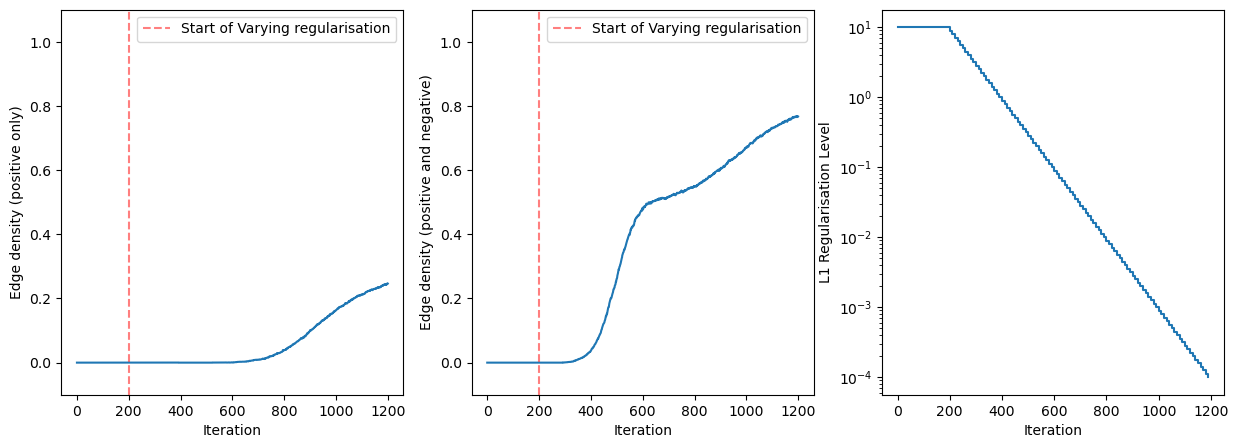

In [66]:
fig,ax = plt.subplots(ncols=3, figsize=(15,5))
q_theta_params = utils.convert_state_dicts(em_stored_vals["q_State_dicts"])
est_precs = torch.stack(q_theta_params["Precision"])
lower_diag = est_precs[:, lower_indices[0], lower_indices[1]]
print(est_precs.shape)
positive_rates = torch.mean((lower_diag>em_pos_quantiles[0]).float(),dim=-1)
abs_positive_rates = torch.mean((torch.abs(lower_diag)>em_abs_quantiles[0]).float(), dim=-1)
ax[0].plot(positive_rates)
ax[1].plot(abs_positive_rates)
ax[2].step(torch.cat((torch.zeros(1),change_points[:-1])), l1_regs, where="post")
ax[2].set_yscale("log")
em_index = torch.min(torch.nonzero(abs_positive_rates>0.5))
# Plot each change point as a vertical red line
for i in range(2):
    ax[i].set_xlabel("Iteration")
    ax[i].set_ylim(-0.1,1.1)
    ax[i].axvline(change_points[0], linestyle="--", color="red", alpha=0.5, label="Start of Varying regularisation")
    ax[i].legend()
ax[0].set_ylabel("Edge density (positive only)")
ax[1].set_ylabel("Edge density (positive and negative)")
ax[2].set_xlabel("Iteration")
ax[2].set_ylabel("L1 Regularisation Level")
print(positive_rates[-1])
print(abs_positive_rates[-1])

### Plot Results

In [ ]:
est_precs = torch.stack([em_stored_vals["q_State_dicts"][index]["Precision"] for index in change_points-1])
true_prec = true_stored_vals["q_State_dicts"][true_index]["Precision"]

# Plot ROC curve from this

est_abs = torch.abs(est_precs)>0.002
true_abs = (torch.abs(true_prec)>0.002).float()
tpr, fpr = utils.data.tpr(true_abs, est_abs ), utils.data.fpr(true_abs, est_abs)
# Append 0 and 1 to begining and end of fpr and tpr
tpr = torch.cat((torch.zeros(1), tpr, torch.ones(1)))
fpr = torch.cat((torch.zeros(1), fpr, torch.ones(1)))
print(f"AUC: {utils.data.AUC(tpr, fpr):.3f}")
# plot line plot with dots at points
plt.plot(fpr, tpr, marker = "o", label="Variational", markersize=3)
plt.show()

AUC: 0.866


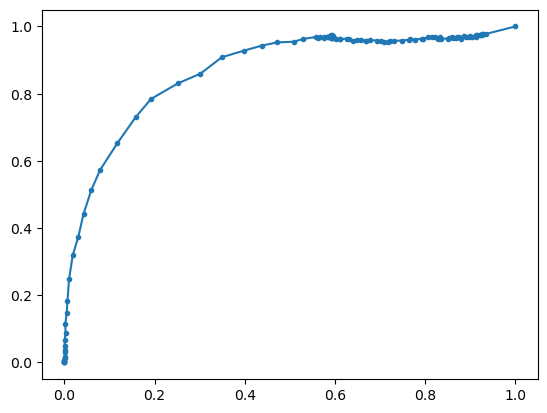

In [ ]:
est_precs = torch.stack([em_stored_vals["q_State_dicts"][index]["Precision"] for index in change_points-1])
true_prec = true_stored_vals["q_State_dicts"][true_index]["Precision"]

# Plot ROC curve from this

est_abs = torch.abs(est_precs)>0.002
true_abs = (torch.abs(torch.tensor(mle_runner.precision_))>0.002).float()
tpr, fpr = utils.data.tpr(true_abs, est_abs ), utils.data.fpr(true_abs, est_abs)
# Append 0 and 1 to begining and end of fpr and tpr
tpr = torch.cat((torch.zeros(1), tpr, torch.ones(1)))
fpr = torch.cat((torch.zeros(1), fpr, torch.ones(1)))
print(f"AUC: {utils.data.AUC(tpr, fpr):.3f}")
# plot line plot with dots at points
plt.plot(fpr, tpr, marker = "o", label="Variational", markersize=3)
plt.show()